<a href="https://colab.research.google.com/github/aadityane93/Deep_Learning/blob/main/topic_5_exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 9.2 — Image Segmentation Exercise

In this notebook you'll build, train, and evaluate a small encoder–decoder
convnet for **semantic segmentation** on the Oxford-IIIT Pets dataset.

Most of the plumbing is filled in for you. The **`# TODO`** sections are where
you put the conceptual pieces from the lecture: the model architecture, the
training configuration, and how to turn raw model output into a visualisable
mask.

There are **5 TODOs** plus an optional **bonus** at the end.

**Recommended runtime:** Colab GPU (Runtime → Change runtime type → GPU).
On a T4 the whole notebook should run in 3–5 minutes once your TODOs are correct.

## 1. Download and list the data

*Nothing to do here — just run these cells.*

In [ ]:
!wget -q http://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
!wget -q http://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz
!tar -xf images.tar.gz
!tar -xf annotations.tar.gz

In [ ]:
import os

input_dir = "images/"
target_dir = "annotations/trimaps/"

input_img_paths = sorted(
    [os.path.join(input_dir, fname)
     for fname in os.listdir(input_dir)
     if fname.endswith(".jpg")])
target_paths = sorted(
    [os.path.join(target_dir, fname)
     for fname in os.listdir(target_dir)
     if fname.endswith(".png") and not fname.startswith(".")])

print(f"{len(input_img_paths)} images, {len(target_paths)} masks")

7390 images, 7390 masks


## 2. Inspect a sample

Show one input image, then its matching mask side by side.

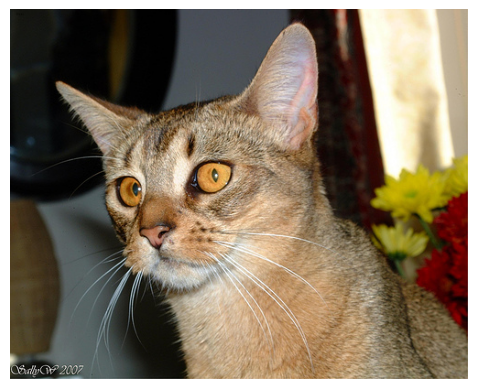

In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.utils import load_img, img_to_array

plt.axis("off")
plt.imshow(load_img(input_img_paths[10]))

### TODO 1 — Display the corresponding target mask

The mask file `target_paths[9]` is a single-channel PNG with integer
pixel values **1, 2, or 3** (foreground / background / contour).

If you `imshow` it directly you'll see almost nothing — values 1, 2, 3 are
all very dark on a 0–255 scale.

**Your task:** complete `display_target` so it remaps those three values
into something visible. *Hint:* try mapping `{1, 2, 3} → {0, 127, 254}`.

TypeError: 'ellipsis' object is not subscriptable

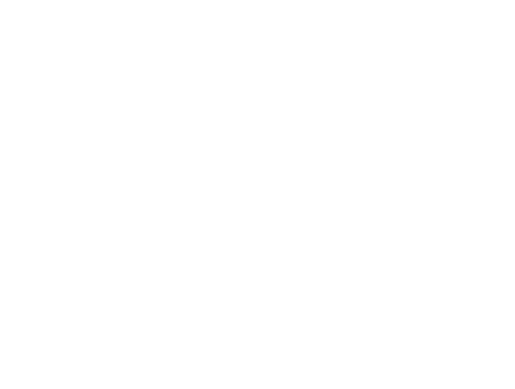

In [ ]:
def display_target(target_array):
    # TODO 1: rescale target_array so the three classes (1, 2, 3) become
    # easily distinguishable grey levels for display.
    normalized_array = (target_array - 1) * 127   # <-- your code
    plt.axis("off")
    plt.imshow(normalized_array[:, :, 0])

img = img_to_array(load_img(target_paths[9], color_mode="grayscale"))
display_target(img)

## 3. Build a fast `tf.data` pipeline

*Provided for you.* Resizes everything to 128 × 128, decodes JPG/PNG
on the fly, caches the decoded tensors in RAM after the first epoch,
and prefetches the next batch while the GPU is busy. We also remap
mask labels from {1, 2, 3} to {0, 1, 2} so they're valid indices for
`sparse_categorical_crossentropy`.

In [ ]:
import tensorflow as tf
import numpy as np

IMG_SIZE = (128, 128)
BATCH = 128
NUM_VAL = 1000

def decode_input(path):
    img = tf.io.read_file(path)
    img = tf.io.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    return tf.cast(img, tf.float32)

def decode_target(path):
    img = tf.io.read_file(path)
    img = tf.io.decode_png(img, channels=1)
    img = tf.image.resize(img, IMG_SIZE, method="nearest")
    return tf.cast(img, tf.uint8) - 1   # 1,2,3 -> 0,1,2

def make_ds(in_paths, tg_paths, training):
    ds = tf.data.Dataset.from_tensor_slices((in_paths, tg_paths))
    ds = ds.map(lambda i, t: (decode_input(i), decode_target(t)),
                num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.cache()
    if training:
        ds = ds.shuffle(512)
    ds = ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_ds(input_img_paths[:-NUM_VAL], target_paths[:-NUM_VAL], training=True)
val_ds   = make_ds(input_img_paths[-NUM_VAL:], target_paths[-NUM_VAL:], training=False)

## 4. Build the encoder–decoder model

Now the part the lecture is really about.

### TODO 2 — Build the encoder

Following the architecture from the book, build the encoder as **6
`Conv2D` layers** with the following filter / stride pattern:

| layer | filters | strides |
|---|---|---|
| 1 | 64  | 2 |
| 2 | 64  | 1 |
| 3 | 128 | 2 |
| 4 | 128 | 1 |
| 5 | 256 | 2 |
| 6 | 256 | 1 |

All layers should use **kernel size 3**, **`activation="relu"`**,
and **`padding="same"`**.

**Hint:** Why are we using strided convolutions instead of `MaxPooling2D`?
If the answer doesn't come to mind, revisit the *“Why Not MaxPooling?”* slide.

### TODO 3 — Build the decoder

Mirror the encoder with **6 `Conv2DTranspose` layers**, in reverse order
of filter counts:

| layer | filters | strides |
|---|---|---|
| 1 | 256 | 1 |
| 2 | 256 | 2 |
| 3 | 128 | 1 |
| 4 | 128 | 2 |
| 5 | 64  | 1 |
| 6 | 64  | 2 |

Same kernel size, activation, and padding as before.

**Hint:** Why is the *output* layer a regular `Conv2D` with `softmax`
instead of a `Conv2DTranspose`? Think about what shape the output needs
to have, and what each pixel position should represent.

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

def get_model(img_size, num_classes):
    inputs = keras.Input(shape=img_size + (3,))
    x = layers.Rescaling(1./255)(inputs)

    # ---- TODO 2: encoder (6 Conv2D layers) ----
    # x = layers.Conv2D(...)(x)
    # ...

    # ---- TODO 3: decoder (6 Conv2DTranspose layers) ----
    # x = layers.Conv2DTranspose(...)(x)
    # ...

    outputs = layers.Conv2D(num_classes, 3, activation="softmax", padding="same")(x)
    return keras.Model(inputs, outputs)

model = get_model(img_size=IMG_SIZE, num_classes=3)
model.summary()

**Sanity check:** `model.summary()` should end with an output shape of
`(None, 128, 128, 3)`. If you see a different spatial size, revisit your
stride pattern — every `strides=2` in the encoder must be matched by exactly
one `strides=2` in the decoder.

## 5. Train the model

### TODO 4 — Compile and fit

Configure training:

1. **Optimizer:** any reasonable choice (`"rmsprop"` or `"adam"` both work).
2. **Loss:** `"sparse_categorical_crossentropy"`. *Why "sparse"?* Because
   our targets are integer indices (shape `(H, W, 1)`), not one-hot vectors
   (shape `(H, W, 3)`).
3. **Callback:** add `keras.callbacks.EarlyStopping(patience=5,
   restore_best_weights=True)` so training stops automatically once the
   validation loss plateaus.
4. Fit on `train_ds`, validate on `val_ds`, with up to **30** epochs
   (EarlyStopping will usually cut you off well before then).

In [ ]:
# TODO 4: compile and fit
# model.compile(optimizer=..., loss=...)
# callbacks = [...]
# history = model.fit(...)

## 6. Plot the training and validation loss

*Provided.* If your TODOs above are right, you should see the validation
loss decrease and then either flatten or start creeping up — that's where
EarlyStopping should have stopped the run.

In [ ]:
h = history.history
ep = range(1, len(h["loss"]) + 1)
plt.figure()
plt.plot(ep, h["loss"], "bo", label="Training loss")
plt.plot(ep, h["val_loss"], "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend(); plt.show()

## 7. Predict and visualise a segmentation mask

### TODO 5 — Convert raw output to a displayable mask

`model.predict(...)` on a single image returns an array of shape
`(H, W, num_classes)` of class probabilities. To turn that into a
visualisable single-channel mask:

1. Take the **argmax** along the class axis (the last one) — this gives an
   integer class label per pixel, shape `(H, W)`, values in `{0, 1, 2}`.
2. Multiply by 127 so the three classes spread out as 0 / 127 / 254 grey
   levels. (This is the same trick as TODO 1 — just for display.)

In [ ]:
from tensorflow.keras.utils import array_to_img

# Grab one validation example
for x_batch, y_batch in val_ds.take(1):
    test_image = x_batch[4]
    break

raw_pred = model.predict(tf.expand_dims(test_image, 0))[0]

def display_mask(pred):
    # TODO 5: turn `pred` of shape (H, W, num_classes) into a displayable single-channel mask of shape (H, W).
    mask = ...   # <-- your code
    plt.axis("off")
    plt.imshow(mask)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
plt.sca(axes[0]); plt.imshow(array_to_img(test_image)); plt.axis("off"); plt.title("input")
plt.sca(axes[1]); display_mask(raw_pred); plt.title("predicted mask")
plt.show()

# What ConvNets Learn — Visualizing Intermediate Activations

**Deep Learning Lecture Exercise — Chapter: What ConvNets Learn**

---

In this exercise you will:
1. Load a pre-trained model
2. Load a real-world image
3. Extract intermediate layer activations
4. Visualize what each filter "sees" at different depths of the network

> ** Goal:** Develop intuition for how convolutional filters evolve from detecting simple edges and textures (early layers) to abstract, high-level concepts (deeper layers).

---

**Estimated time:** ~10-20 minutes  
** Test image:** A dog photo from the web  

## Step 0 — Setup & Imports

Run this cell first. It installs and imports everything you need.

In [ ]:
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
from keras import layers

### Step 1: Load a Pre-trained CNN Model

In this step, you will load a pre-trained Convolutional Neural Network (CNN) model.

- We use **VGG16**, a well-known model trained on the ImageNet dataset  
- The model already learned useful visual features (edges, textures, shapes)  
- We set `include_top=False` to remove the classification layers and keep only the feature extraction part  

 **Your task:**
- Load the pre-trained VGG16 model  
- Display its architecture using `model.summary()`  



In [ ]:

model = keras.applications.VGG16(weights="imagenet", include_top=False)
## Display the architecture

### Step 2: Load and Prepare an Input Image

In this step, you will load an image and prepare it so it can be processed by the CNN.

- Download an image from a URL  
```
https://hips.hearstapps.com/hmg-prod/images/dog-puppy-on-garden-royalty-free-image-1586966191.jpg?crop=0.752xw:1.00xh;0.175xw,0&resize=1200:*
```
- Resize it to the required input size (224 × 224 for VGG16)  
- Convert it into a numerical array  
- Expand its dimensions to match the model’s expected input shape  

 **Your task:**
- Load the image from the given URL  
- Convert it into a tensor suitable for the model  

 **Tips:**
- CNNs expect input in the shape `(batch_size, height, width, channels)`   
- Make sure the target size matches the model input (224, 224)

In [ ]:
def get_img_array(img_path, target_size):
    img = keras.utils.load_img(
      img_path, target_size=target_size)
    array = keras.utils.img_to_array(img)
    array = np.expand_dims(array, axis=0)
    return array

img_path = keras.utils.get_file(
    fname="dog.jpg",
    origin="" #TO DO
)

img_tensor = get_img_array(img_path, target_size=????) # TO DO

### Step 3: Visualize the Input Image

In this step, you will display the image to verify it was loaded and processed correctly.

- Remove axis labels for a cleaner visualization  
- Show the image from the tensor  
- Convert pixel values to a displayable format  

**Your task:**
- Plot the image using matplotlib  

**Tips:**
- Access the image with `img_tensor[0]`
- Use `.astype("uint8")` to correctly display pixel values  

In [ ]:
plt.axis("off")
plt.imshow(???) # TO DO
plt.show()

### Step 4: Extract Activations from Intermediate Layers

In this step, you will create a new model that outputs the **activations** of selected layers.

- Loop through the model layers  
- Select only convolution and pooling layers  
- Store their outputs and names  
- Build a new model that returns these activations  

 **Your task:**
- Collect outputs from `Conv2D` and `MaxPooling2D` layers  
- Create a new model that returns these outputs  

 **Tips:**
- Use `isinstance()` to filter specific layer types  
- Save layer names to help with visualization later  
- The new model will take the same input but return multiple outputs  

In [ ]:
layer_outputs = []
layer_names = []

for layer in model.layers:
    if ???(layer, (layers.Conv2D, layers.MaxPooling2D)): # TO DO
        layer_outputs.append(layer.output)
        layer_names.append(layer.name)

activation_model = keras.Model(inputs=model.input, outputs=layer_outputs)

### Step 5: Compute Feature Map Activations

In this step, you will run the image through the activation model to extract what each selected layer has learned.

- Feed the image into the model  
- Get outputs from all selected convolution and pooling layers  
- Store the resulting feature maps  


 **Your task:**
- Use the activation model to compute activations for the input image by using the `.predict` function.

**Tips:**
- The image was saved earlier as a tensor `img_tensor`





In [ ]:
activations = activation_model.???(???) # TO DO

### Step 6: Visualize Feature Maps from the First Layer

In this step, you will inspect what the first convolutional layer has learned by visualizing its feature maps.

- Select the activations from the first layer (index 0)  
- Check the shape to understand how many filters are present  
- Visualize one feature map (channel) of that layer  

**Your task:**
- Extract the first layer activation  
- Print its shape  
- Display one of its feature maps  

**Tips:**
- The shape is typically `(1, height, width, channels)`  
- Each channel corresponds to a different learned filter  
- Try changing the last index (e.g., `30`) to explore different filters  
- Early layers usually detect simple patterns like edges and textures  

In [ ]:
first_layer_activation = activations[???] #TO DO
print(first_layer_activation.???) # TO DO
plt.matshow(first_layer_activation[0, :, :, ???], cmap="viridis") # TO DO

### Step 7: Visualize Feature Maps Across All Layers

In this final step, you will visualize how different layers of the CNN respond to the input image.

- Loop through all selected layers  
- Display multiple feature maps per layer in a grid (Grid should consist of the following shape:  10 rows
- Compare how representations change from early to deeper layers  

 **Your task:**
- Iterate over all layer activations  
- Build a grid of feature maps for each layer  
- Display the results using matplotlib  

**Tip**
-The shape is  (1, height, width, channels), therefore you must access the last dimension



In [ ]:
images_per_row = ??? #TO DO

for layer_name, layer_activation in zip(layer_names, activations):
    n_features = layer_activation.shape[???]  # TO DO: get the number of channels (last dimension)
    size = layer_activation.shape[1]

    n_cols = n_features // images_per_row
    display_grid = np.zeros(((size + 1) * n_cols - 1,
                             (size + 1) * images_per_row - 1))

    for col in range(n_cols):
        for row in range(images_per_row):
            channel_index = col * images_per_row + row
            channel_image = layer_activation[0, :, :, channel_index]

            # normalize each channel to [0, 255] for visibility
            channel_image -= channel_image.mean()
            channel_image /= channel_image.std() + 1e-5
            channel_image *= 64
            channel_image += 128
            channel_image = np.clip(channel_image, 0, 255).astype("uint8")

            display_grid[col * (size + 1): (col + 1) * size + col,
                         row * (size + 1): (row + 1) * size + row] = channel_image

    scale = 1. / size
    plt.figure(figsize=(scale * display_grid.shape[1],
                        scale * display_grid.shape[0]))
    plt.title(layer_name)
    plt.grid(False)
    plt.axis("off")
    plt.imshow(display_grid, aspect="auto", cmap="viridis")
    plt.show()